## 1. Importações

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random

In [29]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carregar dados do MNIST e separação de treinamento e teste

In [30]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

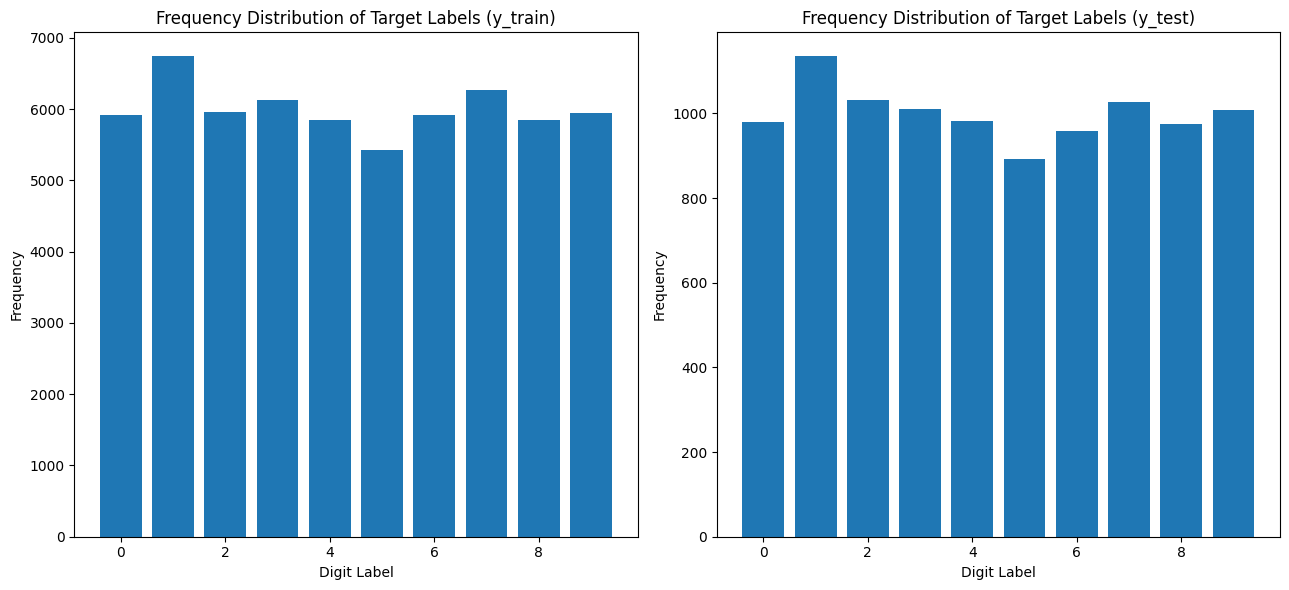

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# y_train
values_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(values_train, counts_train)
axes[0].set_title('Frequency Distribution of Target Labels (y_train)')
axes[0].set_xlabel('Digit Label')
axes[0].set_ylabel('Frequency')

# y_test
values_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(values_test, counts_test)
axes[1].set_title('Frequency Distribution of Target Labels (y_test)')
axes[1].set_xlabel('Digit Label')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_17116\2550392029.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


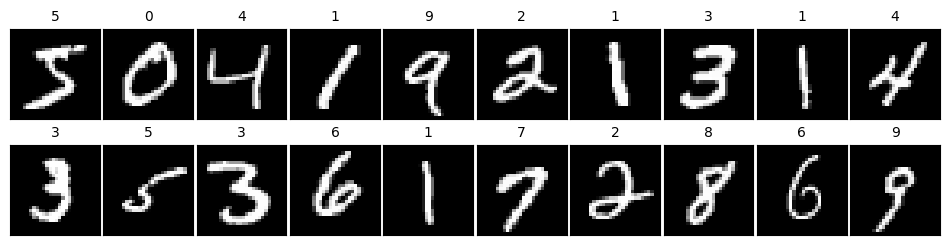

In [32]:
def visualize_images(data):
    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(12,3),
                             gridspec_kw={'wspace':0.04, 'hspace':0.01}, 
                             squeeze=True)
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(x_train[i], cmap='gray')
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(str(y_train[i]), fontsize=10)
        
    plt.tight_layout()
    plt.show()

visualize_images(x_train)

## 3. Pré-processamento:

### a. Normalizar os valores dos pixels para o intervalo [0, 1]

In [33]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### b. Adicionar a dimensão do canal (necessário para CNNs)
As imagens passam de (28, 28) para (28, 28, 1)

In [34]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

## 4. Montar a CNN Rede Neural Convulacional

In [35]:
model = models.Sequential([
    # 1. Data Augmentation
    layers.RandomRotation(0.1, input_shape=(28, 28, 1), seed=SEED), 
    layers.RandomZoom(0.1, seed=SEED),
    
    # 2. Camadas Convolucionais
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 3. Classificador
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5, seed=SEED),
    layers.Dense(10, activation='softmax')
])

c:\Users\Gabriel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### a. Definindo um early stopping

In [37]:
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               restore_best_weights=True,
                               verbose=1)

## 5. Treinamento

In [38]:
historico = model.fit(x_train, y_train, epochs=20, 
                       validation_data=(x_test, y_test),
                       callbacks=[early_stopping])
model.save('modelo.h5')

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8529 - loss: 0.4590 - val_accuracy: 0.9764 - val_loss: 0.0742
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9360 - loss: 0.2129 - val_accuracy: 0.9807 - val_loss: 0.0572
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9506 - loss: 0.1664 - val_accuracy: 0.9872 - val_loss: 0.0434
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9586 - loss: 0.1388 - val_accuracy: 0.9861 - val_loss: 0.0442
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9635 - loss: 0.1265 - val_accuracy: 0.9862 - val_loss: 0.0418
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9662 - loss: 0.1131 - val_accuracy: 0.9873 - val_loss: 0.0414
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9690 - loss: 0.1075 - val_accuracy: 0.9877 - val_loss: 0.0392
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9705 - loss: 0

## 6. Validação

In [39]:
y_pred_probabilidades = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probabilidades, axis=1)
print("\nRelatório de Classificação (Acurácia, Precisão, Cobertura):")
print(classification_report(y_test, y_pred_classes))

# Preparação para Curva ROC (Multi-classe)
classes_unicas = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
y_test_binarizado = label_binarize(y_test, classes=classes_unicas)
n_classes = y_test_binarizado.shape[1]

# Calcular ROC e AUC para cada classe
fpr = dict() 
tpr = dict() 
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarizado[:, i], y_pred_probabilidades[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Relatório de Classificação (Acurácia, Precisão, Cobertura):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### a. Gráficos de Precisão, Perda e ROC Multiclasse

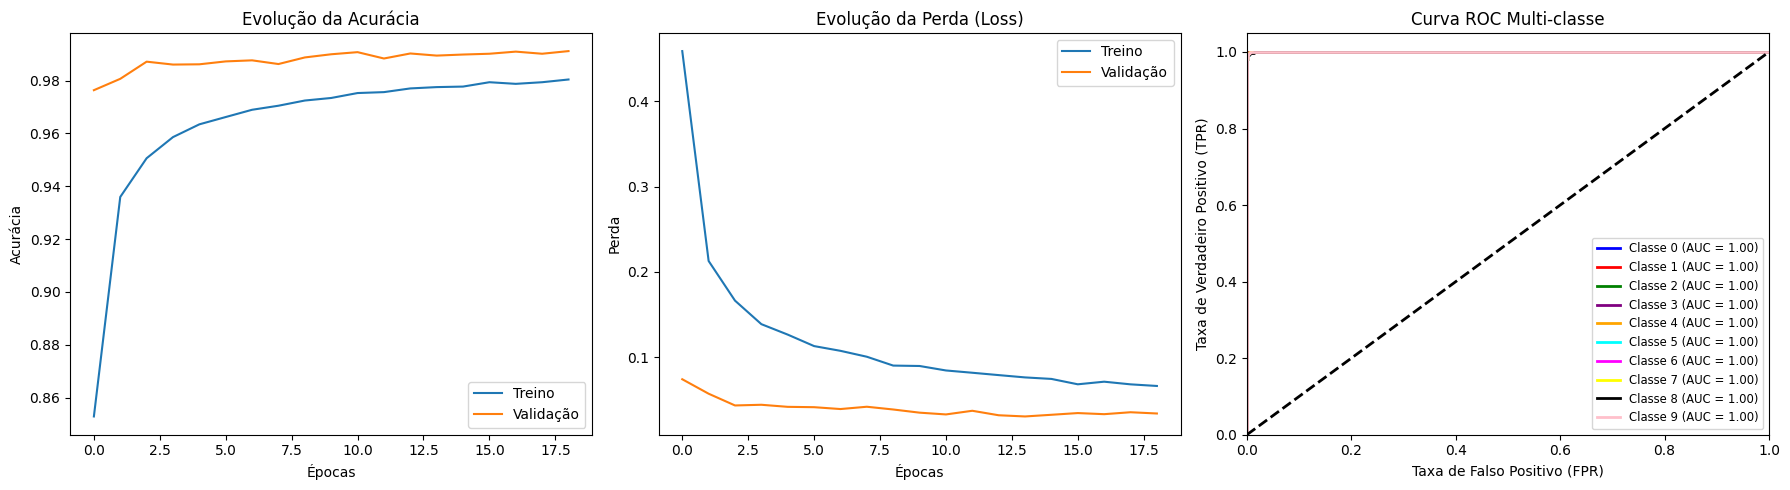

In [40]:
plt.figure(figsize=(18, 5))
# Gráfico 1: Acurácia
plt.subplot(1, 3, 1)
plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
# Gráfico 2: Perda (Loss)
plt.subplot(1, 3, 2)
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
# Gráfico 3: Curva ROC multi-classe
plt.subplot(1, 3, 3)
cores = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'black', 'pink'])
for i, cor in zip(range(n_classes), cores):
    plt.plot(fpr[i], tpr[i], color=cor, lw=2,
             label=f'Classe {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Linha base (aleatória)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC Multi-classe')
plt.legend(loc="lower right", fontsize='small')
plt.tight_layout()
plt.show()

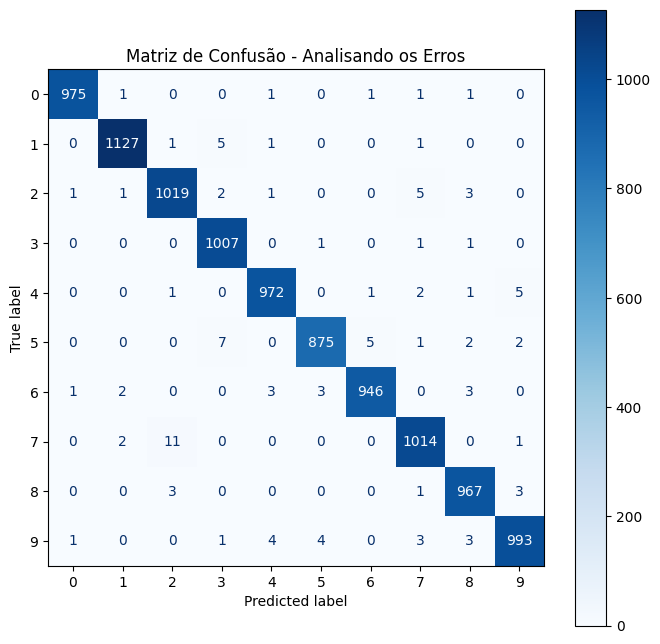

In [41]:
matriz = confusion_matrix(y_test, y_pred_classes)
display = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=classes_unicas)
plt.figure(figsize=(8, 8))
# Usamos cmap='Blues' para um visual acadêmico e limpo
display.plot(cmap='Blues', values_format='d', ax=plt.gca()) 
plt.title('Matriz de Confusão - Analisando os Erros')
plt.show()